# Спектральная кластеризация

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. "Лекция 5: Выявление сообществ в сетях 2. Спектральные методы"
* Документация:
    * https://networkx.org/documentation/stable/reference/generated/networkx.linalg.laplacianmatrix.laplacian_matrix.html
    * https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html
    * https://networkx.org/documentation/stable/reference/generated/networkx.linalg.laplacianmatrix.normalized_laplacian_matrix.html
    * http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
    * http://scikit-learn.org/stable/modules/generated/sklearn.neighbors.radius_neighbors_graph.html
    * http://scikit-learn.org/stable/modules/generated/sklearn.cluster.SpectralClustering.html

## Вопросы для совместного обсуждения

1\. Обсудите основные шаги алгоритмов спектральной кластеризации.

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Загрузите граф карате клуба. Вычислите матрицу Лапласа $\mathbf{L}=\mathbf{D}-\mathbf{A}$ при помощи готовой функции. Найдите собственные значения и собственные векторы матрицы Лапласа. При использовании функции явно укажите, что используется невзвешенная матрица смежности.

Выделите собственный вектор $\mathbf{u}$, отвечающий минимальному ненулевому с.з. $\lambda_i \ne 0$ и выведите его на экран. Преобразуйте $\mathbf{u}$ в индикаторный вектор $\mathbf{f}$ по правилу $\mathbf{f}_i$ = sign($\mathbf{u}_{i})$. 

Визуализируйте $\mathbf{u}$: по горизонтали откладывается номер узла, по вертикали значение соответствующей координаты вектора $\mathbf{u}$

Визуализируйте граф, обозначив цветом узла компоненту, в которую попадает узел в соответствии с найденным разрезом.

- [ ] Проверено на семинаре

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [2]:
G = nx.karate_club_graph()
L = nx.laplacian_matrix(G, weight=None).toarray()

In [3]:
eigenvalues, eigenvectors = np.linalg.eigh(L)

sorted_indices = np.argsort(eigenvalues)
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

In [4]:
u = eigenvectors[:, 1]
print("Собственный вектор u (вектор Фидлера):")
print(u)

Собственный вектор u (вектор Фидлера):
[-0.11213743 -0.04128789  0.02321896 -0.05549978 -0.28460453 -0.32372722
 -0.32372722 -0.052586    0.05160128  0.09280089 -0.28460453 -0.21099295
 -0.1094613  -0.01474197  0.16275078  0.16275078 -0.42276533 -0.10018142
  0.16275078 -0.01363713  0.16275078 -0.10018142  0.16275078  0.15569457
  0.15302558  0.16096292  0.18710956  0.12766405  0.0951523   0.16765031
  0.07349964  0.09875343  0.13034546  0.11890326]


In [5]:
f = np.sign(u)
print("\nИндикаторный вектор f:")
print(f)


Индикаторный вектор f:
[-1. -1.  1. -1. -1. -1. -1. -1.  1.  1. -1. -1. -1. -1.  1.  1. -1. -1.
  1. -1.  1. -1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.]


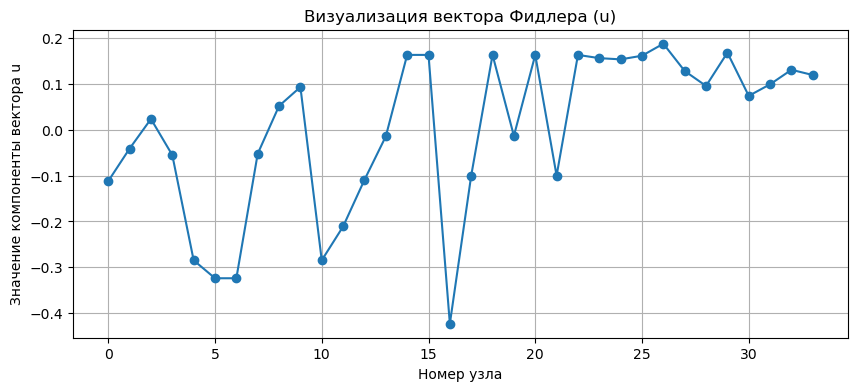

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(range(len(u)), u, marker='o', linestyle='-')
plt.xlabel("Номер узла")
plt.ylabel("Значение компоненты вектора u")
plt.title("Визуализация вектора Фидлера (u)")
plt.grid(True)
plt.show()

/Users/andreyserba/Desktop/anaconda3/lib/python3.12/site-packages/networkx/drawing/nx_pylab.py:457: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


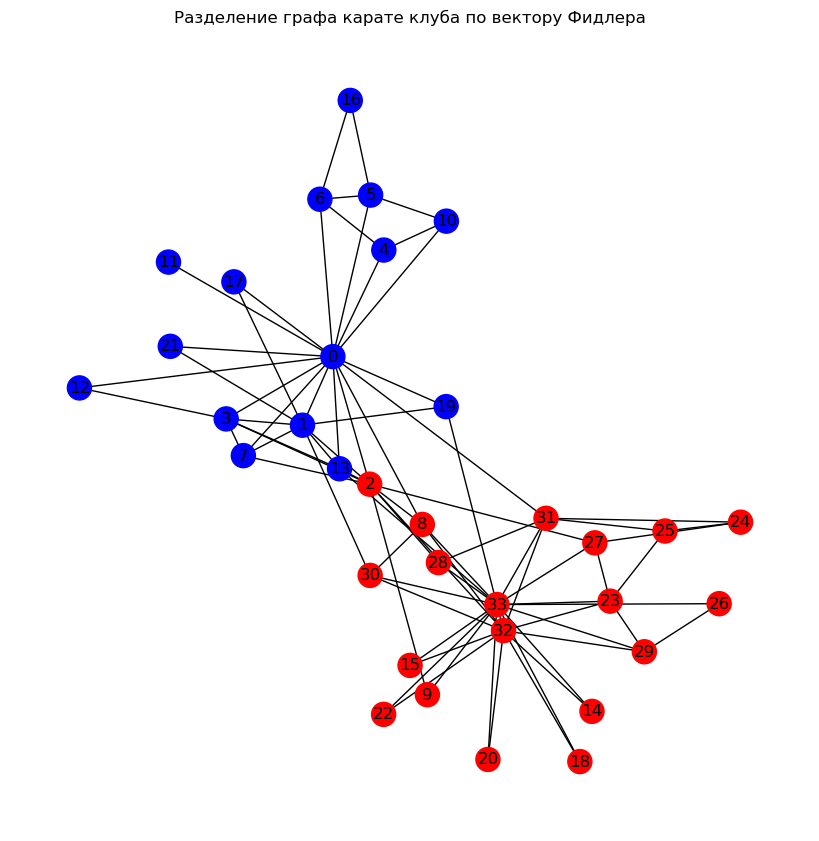

In [7]:
node_colors = ['red' if f_i >= 0 else 'blue' for f_i in f]
pos = nx.spring_layout(G, seed=42) # Используем seed для воспроизводимости

plt.figure(figsize=(8, 8))
nx.draw(G, pos, node_color=node_colors, with_labels=True, node_size=300, cmap=plt.cm.coolwarm)
plt.title("Разделение графа карате клуба по вектору Фидлера")
plt.show()

<p class="task" id="2"></p>

2\. Повторите предыдущую задачу, используя нормализованную матрицу Лапласа $\mathbf{L}_{sym}=\mathbf{D^{-\frac{1}{2}}}\mathbf{L}\mathbf{D^{-\frac{1}{2}}}$. При расчете матрицы Лапласа явно укажите, что используется взвешенная матрица смежности $\mathbf{W}$.


- [ ] Проверено на семинаре

In [8]:
G = nx.karate_club_graph()

In [9]:
L_sym = nx.normalized_laplacian_matrix(G).toarray()

In [10]:
eigenvalues, eigenvectors = np.linalg.eigh(L_sym)

In [11]:
u = eigenvectors[:, 1]
print("Собственный вектор u (из нормализованного Лапласиана):")
print(u)

Собственный вектор u (из нормализованного Лапласиана):
[-0.28814558 -0.14084241 -0.06725901 -0.13436137 -0.23229627 -0.35714964
 -0.34138202 -0.10452288  0.05403598  0.04118929 -0.24697876 -0.08653547
 -0.07836028 -0.07671608  0.1011621   0.11743498 -0.26166942 -0.0746579
  0.0760567  -0.05207837  0.09197806 -0.07934999  0.0989321   0.22645795
  0.12551549  0.18315111  0.13037628  0.14553304  0.05886632  0.18839478
  0.07654081  0.1753748   0.25912862  0.26049118]


In [12]:
f = np.sign(u)
print("\nИндикаторный вектор f:")
print(f)


Индикаторный вектор f:
[-1. -1. -1. -1. -1. -1. -1. -1.  1.  1. -1. -1. -1. -1.  1.  1. -1. -1.
  1. -1.  1. -1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.]


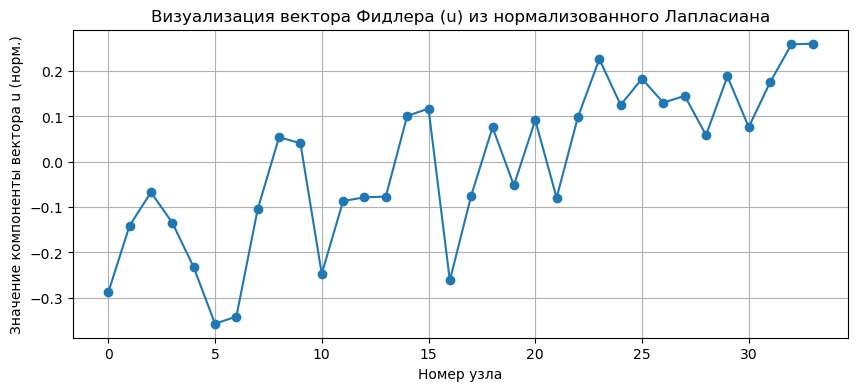

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(range(len(u)), u, marker='o', linestyle='-')
plt.xlabel("Номер узла")
plt.ylabel("Значение компоненты вектора u (норм.)")
plt.title("Визуализация вектора Фидлера (u) из нормализованного Лапласиана")
plt.grid(True)
plt.show()

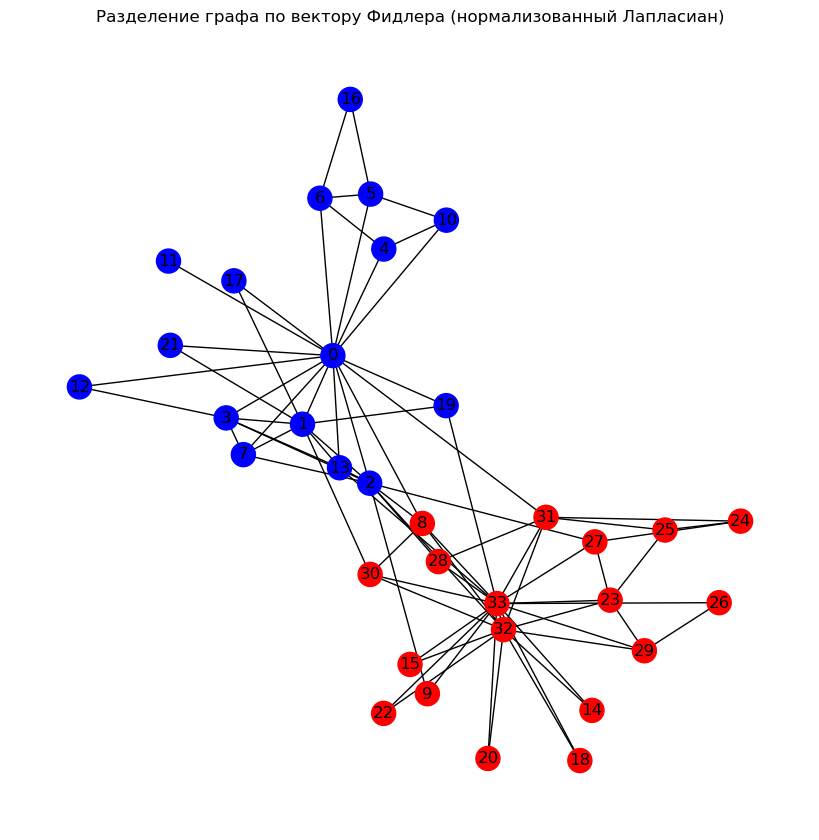

In [14]:
node_colors = ['red' if f_i >= 0 else 'blue' for f_i in f]
pos = nx.spring_layout(G, seed=42) # Используем тот же seed для сравнения

plt.figure(figsize=(8, 8))
nx.draw(G, pos, node_color=node_colors, with_labels=True, node_size=300, cmap=plt.cm.coolwarm)
plt.title("Разделение графа по вектору Фидлера (нормализованный Лапласиан)")
plt.show()

<p class="task" id="3"></p>

3\. Дан набор данных `(X, y`). Визуализируйте набор данных, отрисовав точки на плоскости и раскрасив в цвета, соответствующие меткам объектов `y`. Решите задачу кластеризации данных на 3 кластера при помощи алгоритма KMeans из `sklearn`. Визуализируйте полученный результат.

- [ ] Проверено на семинаре

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

In [16]:
X, y = make_blobs(n_samples=300, random_state=170)
X = np.dot(X, [[0.6, -0.6], [-0.4, 0.8]])

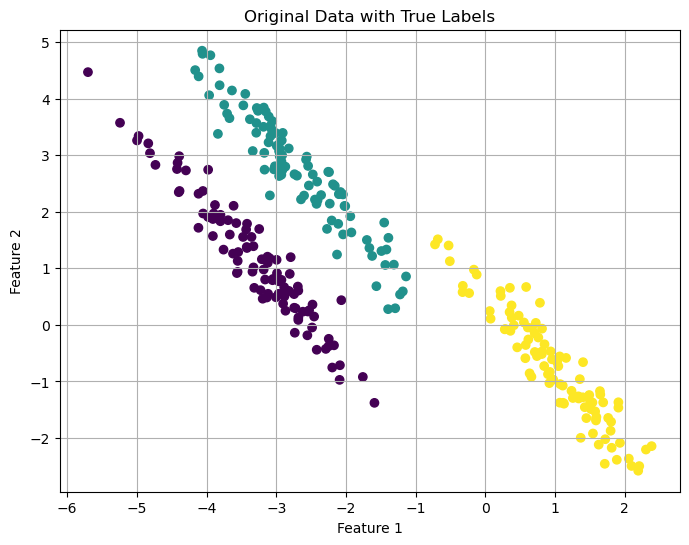

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.title("Original Data with True Labels")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

In [18]:
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) 
kmeans_labels = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

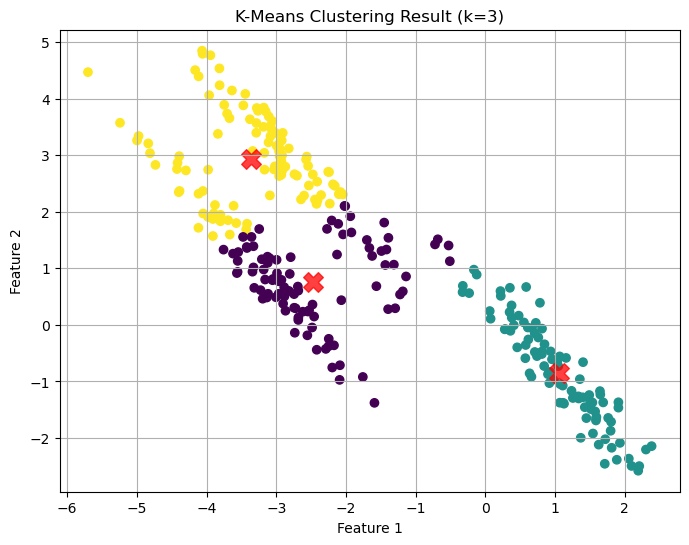

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Cluster Centers')
plt.title(f"K-Means Clustering Result (k={n_clusters})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

<p class="task" id="4"></p>

4\. На основе датасета из предыдущего задания создайте граф при помощи функции `radius_neighbors_graph` из `sklearn` (укажите аргумент `radius=1`). Получите матрицу $U \in \mathbb{R}^{300\times3}$, состояющую из собственных векторов матрицы Лапласа, соответствующих трем наименьшим ненулевым собственным значениям. Решите задачу кластеризации при помощи алгоритма KMeans из `sklearn` на основе матрицы $U$. Визуализируйте полученный результат.

- [ ] Проверено на семинаре

In [20]:
from sklearn.neighbors import radius_neighbors_graph
from scipy.sparse.csgraph import laplacian
from scipy.sparse.linalg import eigsh
from sklearn.cluster import KMeans

In [21]:
X, y = make_blobs(n_samples=300, random_state=170)
X = np.dot(X, [[0.6, -0.6], [-0.4, 0.8]])
n_samples = X.shape[0]
n_clusters = 3

In [22]:
A = radius_neighbors_graph(X, radius=1, mode='connectivity', include_self=False)

In [23]:
L = laplacian(A, normed=False)

num_eigenvectors_to_compute = n_clusters + 1 
eigenvalues, eigenvectors = eigsh(L, k=num_eigenvectors_to_compute, which='SM')

In [24]:
U = eigenvectors[:, 1:n_clusters+1]
print("Shape of matrix U:", U.shape) 

Shape of matrix U: (300, 3)


In [25]:
kmeans_spectral = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
spectral_labels = kmeans_spectral.fit_predict(U)

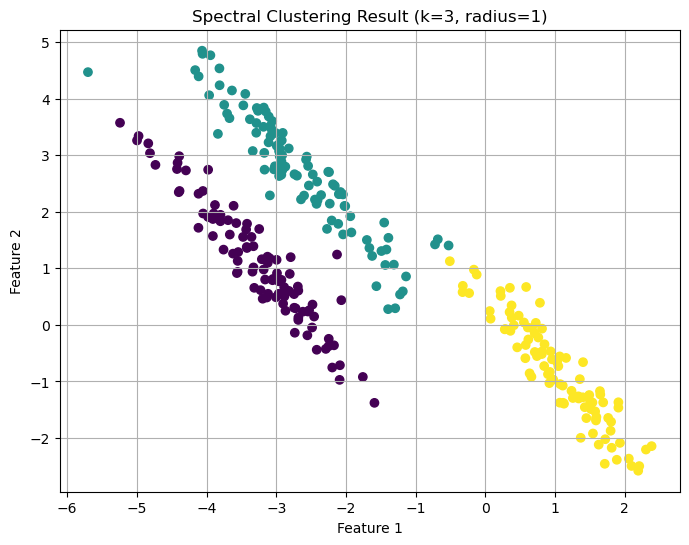

In [26]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=spectral_labels, cmap='viridis')
plt.title(f"Spectral Clustering Result (k={n_clusters}, radius=1)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

<p class="task" id="5"></p>

5\. Решите задачу кластеризации данных на 3 кластера при помощи алгоритма `SpectralClustering` из `sklearn`. Визуализируйте полученный результат. При создании модели кластеризации укажите значение аргумента `affinity='nearest_neighbors'`.

- [ ] Проверено на семинаре

In [27]:
from sklearn.cluster import SpectralClustering

In [28]:
X, y = make_blobs(n_samples=300, random_state=170)
X = np.dot(X, [[0.6, -0.6], [-0.4, 0.8]])
n_clusters = 3

In [29]:
spectral_model = SpectralClustering(n_clusters=n_clusters,
                                    affinity='nearest_neighbors',
                                    random_state=42)
spectral_labels = spectral_model.fit_predict(X)

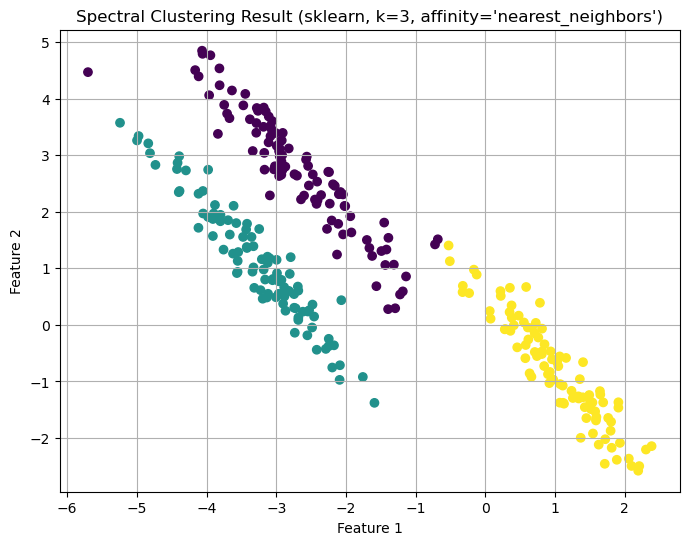

In [30]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=spectral_labels, cmap='viridis')
plt.title(f"Spectral Clustering Result (sklearn, k={n_clusters}, affinity='nearest_neighbors')")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()